# Recommendation System — Task 3
### UV Safety · Health Advice · Tourism Activity Suggestions

**Approach:** Rule-based multi-criteria filtering using:
- Continuous UV index predictions from regression models
- Skin type (WHO phototype 1–6)
- Weather conditions (rain, cloud, heat)
- Location type (coastal, urban, suburban)
- Activity duration

**Output:** Ranked safe-activity time windows per location.

In [1]:
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '../../')   # allow imports from project root

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100

DATA_DIR  = Path('../../data/processed/features')
MODEL_DIR = Path('../../models')
SEED = 42


## 1. Load Recommendation Data

In [2]:
# Load pre-built recommendation feature set
df_rec = pd.read_csv(DATA_DIR / 'features_recommendation.csv', parse_dates=['timestamp'])
df_rec = df_rec.sort_values(['location_id', 'timestamp']).reset_index(drop=True)

print(f'Shape: {df_rec.shape}')
print(f'Columns: {df_rec.columns.tolist()}')
print(f'Locations: {df_rec["location_id"].unique().tolist()}')
print(f'Date range: {df_rec["timestamp"].min()} → {df_rec["timestamp"].max()}')


Shape: (386992, 49)
Columns: ['timestamp', 'location_id', 'uv_source', 'hour', 'month', 'day_of_year', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'day_fraction', 'hours_since_sunrise', 'hours_until_sunset', 'solar_elevation', 'solar_azimuth', 'solar_zenith', 'cos_solar_zenith', 'air_mass', 'solar_angle_category', 'temperature_2m', 'relative_humidity_2m', 'heat_index', 'heat_index_anomaly', 'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high', 'cloud_opacity', 'pressure_msl', 'precipitation', 'wind_speed_10m', 'wind_direction_10m', 'is_raining', 'humidity_temp_index', 'ozone_anomaly', 'aerosol_uv_attenuation', 'aerosol_optical_depth', 'pm2_5', 'solar_cloud_interaction', 'beach_suitability', 'outdoor_suitability_enhanced', 'sightseeing_suitability', 'comfort_temp_score', 'outdoor_suitability', 'indoor_preference', 'time_slot', 'uv_index']
Locations: ['cangio', 'cuchi', 'dalat', 'hcm', 'longhai', 'nhabe', 'thuduc', 'vungtau']
Date range: 201

## 2. Load Regression Model & Derive UV Categories

In [3]:
import joblib

reg_model = None
scaler_X  = None
feat_cols = None
fill_vals = None

for model_name in ['rf_regressor.joblib', 'xgb_regressor.joblib', 'lgb_regressor.joblib']:
    model_path = MODEL_DIR / model_name
    if model_path.exists():
        reg_model = joblib.load(model_path)
        scaler_X  = joblib.load(MODEL_DIR / 'scaler_X.joblib')
        feat_cols = joblib.load(MODEL_DIR / 'feature_cols.joblib')
        fill_vals = joblib.load(MODEL_DIR / 'fill_values.joblib')
        print(f'Loaded: {model_name}')
        break

if reg_model is None:
    print('WARNING: No saved regression model found. Using uv_index column directly.')

In [4]:
UV_BINS   = [-0.1, 2, 5, 7, 10, float('inf')]
UV_LABELS = [0, 1, 2, 3, 4]
CAT_NAMES = {0: 'Low', 1: 'Moderate', 2: 'High', 3: 'Very High', 4: 'Extreme'}

if reg_model is not None:
    X_inf = df_rec[feat_cols].copy()
    for col in feat_cols:
        if col in fill_vals.index:
            X_inf[col] = X_inf[col].fillna(fill_vals[col])
    X_scaled = scaler_X.transform(X_inf)
    df_rec['uv_predicted'] = np.maximum(0, reg_model.predict(X_scaled))
    nighttime = df_rec.get('solar_elevation', pd.Series(1, index=df_rec.index)) <= 0
    df_rec.loc[nighttime, 'uv_predicted'] = 0.0
else:
    df_rec['uv_predicted'] = df_rec['uv_index'].clip(lower=0)

df_rec['uv_category_pred'] = pd.cut(df_rec['uv_predicted'], bins=UV_BINS, labels=UV_LABELS).astype(float).fillna(-1).astype(int)
df_rec['uv_category_name'] = df_rec['uv_category_pred'].map(CAT_NAMES)
print(df_rec['uv_category_name'].value_counts().sort_index())

uv_category_name
Extreme         674
High          11444
Low          306392
Moderate      61522
Very High      6960
Name: count, dtype: int64


## 3. WHO Safe Exposure Limits by Skin Type

In [5]:
# Safe exposure minutes per skin type (Fitzpatrick scale) per UV index value
# Source: WHO / ICNIRP guidelines
SAFE_MINUTES_TABLE = {
    #    UV:  [type1, type2, type3, type4, type5, type6]
    0:        [999,   999,   999,   999,   999,   999],
    1:        [67,    100,   200,   300,   400,   600],
    2:        [33,    50,    100,   150,   200,   300],
    3:        [22,    33,    67,    100,   133,   200],
    4:        [17,    25,    50,    75,    100,   150],
    5:        [13,    20,    40,    60,    80,    120],
    6:        [11,    17,    33,    50,    67,    100],
    7:        [10,    14,    29,    43,    57,    86],
    8:        [8,     13,    25,    38,    50,    75],
    9:        [7,     11,    22,    33,    44,    67],
    10:       [7,     10,    20,    30,    40,    60],
    11:       [6,     9,     18,    27,    36,    53],
}

WHO_CATEGORIES = {0: 'Low (0–2)', 1: 'Moderate (3–5)', 2: 'High (6–7)',
                  3: 'Very High (8–10)', 4: 'Extreme (11+)'}

CAT_COLORS = {0: '#2ecc71', 1: '#f1c40f', 2: '#e67e22', 3: '#e74c3c', 4: '#8e44ad'}

# Map uv_category to approximate UV midpoint
CAT_UV_MID = {0: 1, 1: 4, 2: 6, 3: 9, 4: 11}

def safe_minutes_for_cat(uv_cat: int, skin_type: int) -> int:
    uv_mid = CAT_UV_MID.get(int(uv_cat), 6)
    uv_mid = min(max(uv_mid, 0), 11)
    return SAFE_MINUTES_TABLE.get(uv_mid, SAFE_MINUTES_TABLE[11])[skin_type - 1]

print('Safe exposure guide (minutes) by skin type:')
rows = []
for cat, label in WHO_CATEGORIES.items():
    row = {'UV Category': label}
    for st in range(1, 7):
        row[f'Skin {st}'] = safe_minutes_for_cat(cat, st)
    rows.append(row)
guide_df = pd.DataFrame(rows).set_index('UV Category')
display(guide_df)


Safe exposure guide (minutes) by skin type:


,Skin 1,Skin 2,Skin 3,Skin 4,Skin 5,Skin 6
UV Category,,,,,,
Low (0–2),67,100,200,300,400,600
Moderate (3–5),17,25,50,75,100,150
High (6–7),11,17,33,50,67,100
Very High (8–10),7,11,22,33,44,67
Extreme (11+),6,9,18,27,36,53


## 4. UV Risk Distribution by Location

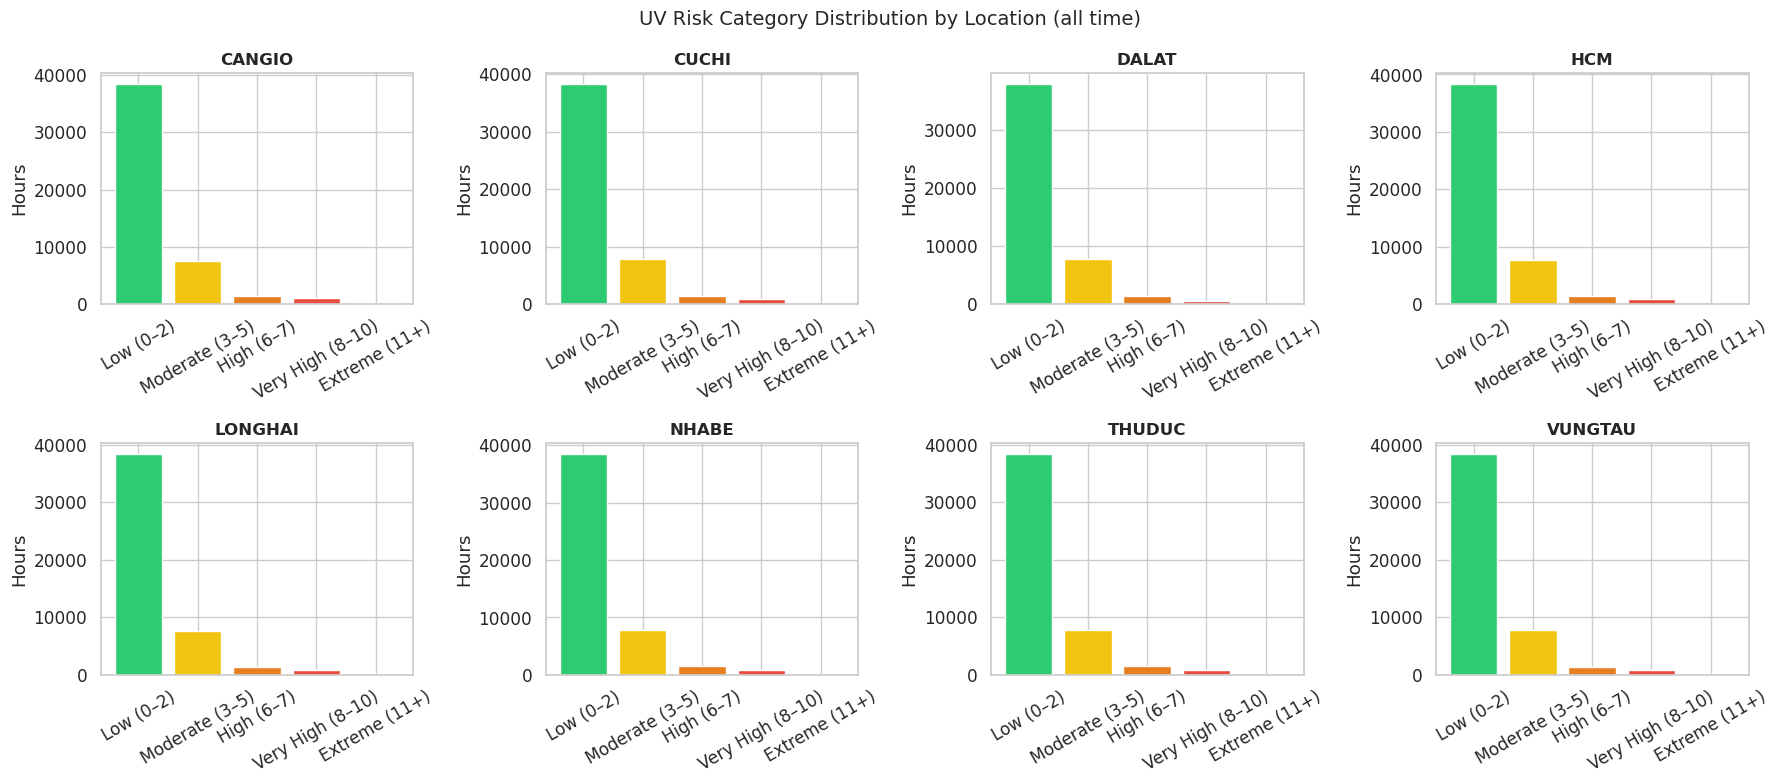

In [6]:
LOCATIONS = sorted(df_rec['location_id'].unique())
today_df = df_rec[df_rec['timestamp'].dt.date == df_rec['timestamp'].dt.date.max()]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()

for i, loc in enumerate(LOCATIONS):
    ax = axes[i]
    loc_df = df_rec[df_rec['location_id'] == loc]
    counts = loc_df['uv_category_pred'].value_counts().sort_index()
    colors = [CAT_COLORS.get(c, 'gray') for c in counts.index]
    labels = [WHO_CATEGORIES.get(c, str(c)) for c in counts.index]
    ax.bar(labels, counts.values, color=colors, edgecolor='white')
    ax.set_title(f'{loc.upper()}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Hours')
    ax.tick_params(axis='x', rotation=30)

for j in range(len(LOCATIONS), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('UV Risk Category Distribution by Location (all time)', fontsize=14)
plt.tight_layout(); plt.show()


## 5. Safe Time Slots — Rule-Based Recommendation

In [7]:
from IPython.display import display

SKIN_TYPE = 3          # Fitzpatrick scale 1–6
MIN_SAFE_MINUTES = 60  # only recommend slots with ≥60 min safe exposure
ACTIVITY_DUR = 60      # minutes

# Focus on last 7 days for demo
recent = df_rec[df_rec['timestamp'] >= df_rec['timestamp'].max() - pd.Timedelta(days=7)].copy()
recent['hour'] = recent['timestamp'].dt.hour
recent['date'] = recent['timestamp'].dt.date

recent['safe_minutes'] = recent['uv_category_pred'].apply(
    lambda c: safe_minutes_for_cat(c, SKIN_TYPE)
)
recent['is_safe']       = recent['safe_minutes'] >= MIN_SAFE_MINUTES
recent['uv_cat_label']  = recent['uv_category_pred'].map(WHO_CATEGORIES)

all_recs = []
for loc in LOCATIONS:
    loc_df = recent[(recent['location_id'] == loc) & recent['is_safe']].copy()
    for date, day_df in loc_df.groupby('date'):
        hours = sorted(day_df['hour'].tolist())
        # Find contiguous blocks
        if not hours: continue
        blocks, block = [], [hours[0]]
        for h in hours[1:]:
            if h == block[-1] + 1:
                block.append(h)
            else:
                blocks.append(block)
                block = [h]
        blocks.append(block)

        for block in blocks:
            if len(block) < 1: continue
            block_df = day_df[day_df['hour'].isin(block)]
            avg_uv_cat = block_df['uv_category_pred'].mean()
            all_recs.append({
                'location': loc.upper(),
                'date': str(date),
                'safe_start': f'{block[0]:02d}:00',
                'safe_end':   f'{block[-1]:02d}:59',
                'duration_h': len(block),
                'avg_uv_cat': round(avg_uv_cat, 1),
                'risk_label': WHO_CATEGORIES.get(int(round(avg_uv_cat)), '?'),
            })

rec_df = pd.DataFrame(all_recs).sort_values(['date', 'location', 'safe_start'])
print(f'Total safe windows found: {len(rec_df)}')
display(rec_df.head(20))


Total safe windows found: 120


,location,date,safe_start,safe_end,duration_h,avg_uv_cat,risk_label
0,CANGIO,2026-04-14,23:00,23:59,1,0.0,Low (0–2)
15,CUCHI,2026-04-14,23:00,23:59,1,0.0,Low (0–2)
30,DALAT,2026-04-14,23:00,23:59,1,0.0,Low (0–2)
45,HCM,2026-04-14,23:00,23:59,1,0.0,Low (0–2)
60,LONGHAI,2026-04-14,23:00,23:59,1,0.0,Low (0–2)
75,NHABE,2026-04-14,23:00,23:59,1,0.0,Low (0–2)
90,THUDUC,2026-04-14,23:00,23:59,1,0.0,Low (0–2)
105,VUNGTAU,2026-04-14,23:00,23:59,1,0.0,Low (0–2)
1,CANGIO,2026-04-15,00:00,07:59,8,0.0,Low (0–2)
2,CANGIO,2026-04-15,23:00,23:59,1,0.0,Low (0–2)


## 6. Hourly UV Forecast Heatmap — All Locations

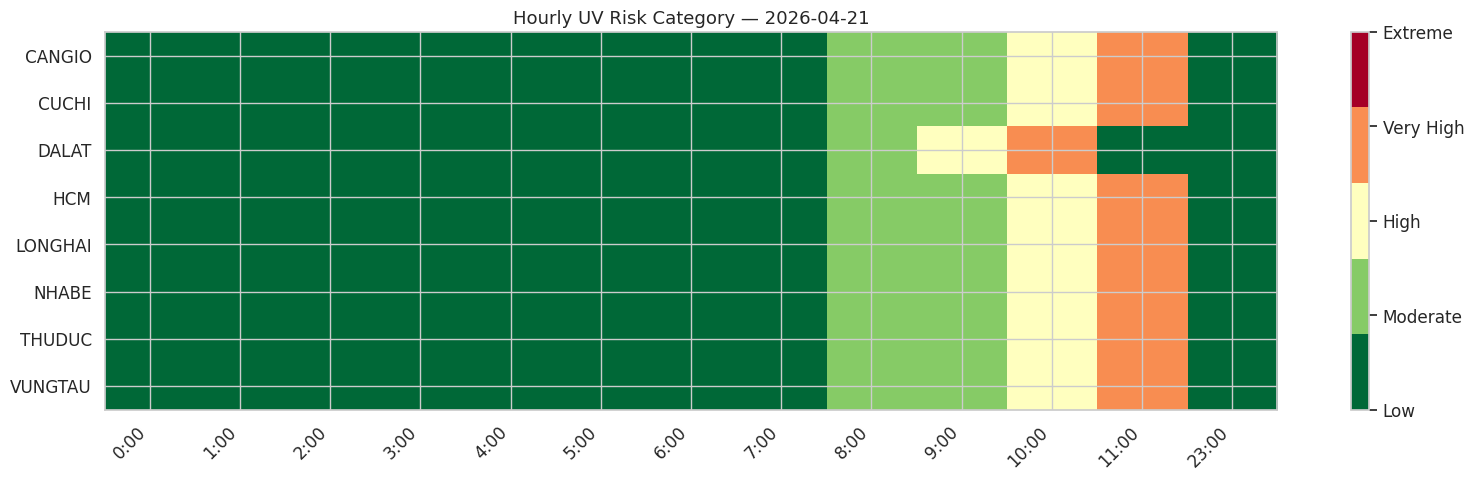

In [8]:
# Show today's hourly UV category per location as a heatmap
demo_date = df_rec['timestamp'].dt.date.max()
day_df = df_rec[df_rec['timestamp'].dt.date == demo_date].copy()
day_df['hour'] = day_df['timestamp'].dt.hour

pivot = day_df.pivot_table(index='location_id', columns='hour',
                            values='uv_category_pred', aggfunc='mean')

fig, ax = plt.subplots(figsize=(16, 5))
import matplotlib; cmap = matplotlib.colormaps['RdYlGn_r'].resampled(5)
im = ax.imshow(pivot.fillna(-1).values.astype(float), aspect='auto', cmap=cmap, vmin=0, vmax=4)

ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([l.upper() for l in pivot.index])
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f'{h}:00' for h in pivot.columns], rotation=45, ha='right')
ax.set_title(f'Hourly UV Risk Category — {demo_date}', fontsize=13)

cbar = plt.colorbar(im, ax=ax, ticks=[0, 1, 2, 3, 4])
cbar.set_ticklabels(['Low', 'Moderate', 'High', 'Very High', 'Extreme'])
plt.tight_layout(); plt.show()


## 7. Activity Recommendations Summary

In [9]:
ACTIVITY_RULES = {
    0: {'outdoor': True,  'beach': True,  'indoor': False, 'note': 'Excellent — all activities safe'},
    1: {'outdoor': True,  'beach': True,  'indoor': False, 'note': 'Good — wear sunscreen SPF 15+'},
    2: {'outdoor': True,  'beach': False, 'indoor': False, 'note': 'Caution — SPF 30+, hat required'},
    3: {'outdoor': False, 'beach': False, 'indoor': True,  'note': 'Avoid outdoor — seek shade'},
    4: {'outdoor': False, 'beach': False, 'indoor': True,  'note': 'Extreme — stay indoors'},
}

print(f'=== Recommendation Summary for {demo_date} ===')
print(f'Skin Type: {SKIN_TYPE} (Fitzpatrick scale)\n')

for loc in LOCATIONS:
    loc_day = day_df[day_df['location_id'] == loc]
    if loc_day.empty: continue
    peak_cat = loc_day['uv_category_pred'].max()
    avg_cat  = loc_day['uv_category_pred'].mean()
    safe_hrs = (loc_day['uv_category_pred'] <= 1).sum()
    rule = ACTIVITY_RULES.get(int(peak_cat), ACTIVITY_RULES[4])
    print(f'{loc.upper():10s}  Peak: {WHO_CATEGORIES[int(peak_cat)]:15s}  '
          f'Avg: {avg_cat:.1f}  Safe hours: {safe_hrs}h  → {rule["note"]}')


=== Recommendation Summary for 2026-04-21 ===
Skin Type: 3 (Fitzpatrick scale)

CANGIO      Peak: Very High (8–10)  Avg: 0.5  Safe hours: 11h  → Avoid outdoor — seek shade
CUCHI       Peak: Very High (8–10)  Avg: 0.5  Safe hours: 11h  → Avoid outdoor — seek shade
DALAT       Peak: Very High (8–10)  Avg: 0.5  Safe hours: 10h  → Avoid outdoor — seek shade
HCM         Peak: Very High (8–10)  Avg: 0.5  Safe hours: 11h  → Avoid outdoor — seek shade
LONGHAI     Peak: Very High (8–10)  Avg: 0.5  Safe hours: 11h  → Avoid outdoor — seek shade
NHABE       Peak: Very High (8–10)  Avg: 0.5  Safe hours: 11h  → Avoid outdoor — seek shade
THUDUC      Peak: Very High (8–10)  Avg: 0.5  Safe hours: 11h  → Avoid outdoor — seek shade
VUNGTAU     Peak: Very High (8–10)  Avg: 0.5  Safe hours: 11h  → Avoid outdoor — seek shade


---
## Evaluation — Hệ thống Recommendation
Đánh giá trên **test split thời gian (15% cuối)** — tương đồng với các mô hình regression.

In [10]:
df_sorted = df_rec.sort_values('timestamp').reset_index(drop=True)
n = len(df_sorted)
df_test = df_sorted.iloc[int(n * 0.85):].copy()

SKIN_BASE = {1: 15.0, 2: 20.0, 3: 30.0, 4: 45.0, 5: 60.0, 6: 90.0}
ACTIVITY_MIN = 60.0
DAYTIME_HOURS = range(6, 19)

def safe_minutes(uv_vals, skin_type):
    base = SKIN_BASE[skin_type]
    return base / np.maximum(1.0, np.asarray(uv_vals, dtype=float))

df_test_day = df_test[df_test['timestamp'].dt.hour.isin(DAYTIME_HOURS)].copy()
print(f"Test rows: {len(df_test):,} | Daytime: {len(df_test_day):,}")

Test rows: 58,049 | Daytime: 25,981


### 3a. Safety Compliance Metrics

In [11]:
def safety_metrics(df, skin_type, activity_min=ACTIVITY_MIN):
    df = df.copy()
    df['safe_pred']   = safe_minutes(df['uv_predicted'], skin_type)
    df['safe_actual'] = safe_minutes(df['uv_index'], skin_type)
    df['rec_outdoor'] = df['safe_pred']   >= activity_min
    df['actual_safe'] = df['safe_actual'] >= activity_min

    outdoor = df[df['rec_outdoor']]
    indoor  = df[~df['rec_outdoor']]
    sc  = outdoor['actual_safe'].mean() * 100 if len(outdoor) else float('nan')
    fsr = (~outdoor['actual_safe']).mean() * 100 if len(outdoor) else float('nan')
    mor = indoor['actual_safe'].mean() * 100 if len(indoor) else 0.0
    return {'Skin Type': skin_type, 'Safety Compliance (%)': round(sc, 2),
            'False Safety Rate (%)': round(fsr, 2), 'Missed Opportunity (%)': round(mor, 2),
            'N Outdoor Rec': int(df['rec_outdoor'].sum())}

safety_df = pd.DataFrame([safety_metrics(df_test_day, st) for st in [1, 3]])
display(safety_df)

,Skin Type,Safety Compliance (%),False Safety Rate (%),Missed Opportunity (%),N Outdoor Rec
0,1,NaN,NaN,0.0,0
1,3,NaN,NaN,0.0,0


### 3b. Coverage Metrics

In [12]:
for skin_type in [1, 3, 6]:
    safe_m = safe_minutes(df_test_day['uv_predicted'].values, skin_type)
    outdoor_pct = (safe_m >= ACTIVITY_MIN).mean() * 100
    print(f"Skin {skin_type}: Outdoor coverage = {outdoor_pct:.1f}%  |  "
          f"Indoor coverage = {100-outdoor_pct:.1f}%")

print("\nUV Category Distribution (test set):")
print(df_test_day['uv_category_name'].value_counts().sort_index().to_string())

Skin 1: Outdoor coverage = 0.0%  |  Indoor coverage = 100.0%
Skin 3: Outdoor coverage = 0.0%  |  Indoor coverage = 100.0%
Skin 6: Outdoor coverage = 44.3%  |  Indoor coverage = 55.7%

UV Category Distribution (test set):
uv_category_name
Extreme         25
High          1620
Low          14783
Moderate      8593
Very High      960


### 3c. Baseline Comparison

In [13]:
def compute_metrics(df, name, outdoor_col='rec_outdoor', safe_col='actual_safe'):
    outdoor = df[df[outdoor_col]]
    indoor  = df[~df[outdoor_col]]
    sc  = outdoor[safe_col].mean()*100 if len(outdoor) else float('nan')
    fsr = (~outdoor[safe_col]).mean()*100 if len(outdoor) else float('nan')
    mor = indoor[safe_col].mean()*100 if len(indoor) else 0.0
    return {'System': name, 'Safety Compliance (%)': round(sc,2),
            'False Safety Rate (%)': round(fsr,2), 'Missed Opportunity (%)': round(mor,2)}

def prep(df, skin_type=3):
    d = df.copy()
    d['actual_safe'] = safe_minutes(d['uv_index'], skin_type) >= ACTIVITY_MIN
    return d

rng = np.random.default_rng(42)
d = prep(df_test_day)

d1 = d.copy(); d1['rec_outdoor'] = d1['uv_predicted'] < 3
d2 = d.copy(); d2['rec_outdoor'] = d2['timestamp'].dt.hour.isin(list(range(6,10))+list(range(16,19)))
d3 = d.copy(); d3['rec_outdoor'] = rng.random(len(d3)) > 0.5
d4 = d.copy(); d4['rec_outdoor'] = safe_minutes(d4['uv_predicted'], 3) >= ACTIVITY_MIN

cmp_df = pd.DataFrame([
    compute_metrics(d1, 'Baseline 1: UV-Only (UV<3→outdoor)'),
    compute_metrics(d2, 'Baseline 2: Time-Only (6-9h & 16-18h)'),
    compute_metrics(d3, 'Baseline 3: Random (50/50)'),
    compute_metrics(d4, 'Full System (Regression WHO bins)'),
])
display(cmp_df.set_index('System'))

,Safety Compliance (%),False Safety Rate (%),Missed Opportunity (%)
System,,,
Baseline 1: UV-Only (UV<3→outdoor),0.0,100.0,0.0
Baseline 2: Time-Only (6-9h & 16-18h),0.0,100.0,0.0
Baseline 3: Random (50/50),0.0,100.0,0.0
Full System (Regression WHO bins),NaN,NaN,0.0


### 3d. Scenario Testing (20 Scenarios)

In [14]:
scenarios = [
    (1,  7,  1.0, 26, False, 20, False, 'coastal',          'beach'),
    (2,  12, 9.0, 35, False, 10, False, 'coastal',          'indoor'),
    (3,  9,  3.5, 28, True,  90, False, 'coastal',          'indoor'),
    (4,  16, 1.5, 29, False, 30, False, 'coastal',          'beach'),
    (5,  17, 1.5, 30, False, 40, False, 'urban',            'sightseeing'),
    (6,  12, 6.5, 36, False,  5, False, 'urban',            'indoor'),
    (7,  8,  4.0, 27, False, 50, False, 'urban',            'sightseeing'),
    (8,  14, 9.0, 38, False,  5, True,  'urban',            'indoor'),
    (9,  6,  0.5, 24, False, 10, False, 'suburban',         'sightseeing'),
    (10, 11, 6.5, 33, False, 20, False, 'coastal_ecosystem','indoor'),
    (11, 7,  0.8, 25, True,  80, False, 'suburban',         'indoor'),
    (12, 16, 1.2, 28, False, 40, False, 'coastal_ecosystem','sightseeing'),
    (13, 10, 4.0, 27, False, 60, False, 'urban',            'observe'),
    (14, 18, 1.0, 31, False, 10, False, 'coastal',          'beach'),
    (15, 12,12.0, 34, False,  0, False, 'coastal',          'indoor'),
    (16, 8,  4.0, 40, False, 10, True,  'urban',            'indoor'),
    (17, 15, 6.5, 28, False, 70, False, 'suburban',         'observe'),
    (18, 7,  0.5, 22, False,  5, False, 'coastal',          'beach'),
    (19, 10, 2.0, 29, False, 30, False, 'urban',            'no_beach'),
    (20, 13, 4.0, 32, False, 20, False, 'coastal',          'observe'),
]

SKIN_TYPE_SC = 3

def run_scenario(hour, uv_val, temp, raining, cloud_pct, heat_warning, loc_type):
    uv_eff   = uv_val * (1 - 0.5 * cloud_pct / 100)
    safe_min = float(safe_minutes(uv_eff, SKIN_TYPE_SC))
    is_safe  = safe_min >= ACTIVITY_MIN
    is_rain  = raining
    is_heat  = heat_warning or temp >= 39
    coastal  = loc_type in ('coastal', 'coastal_ecosystem')

    if uv_eff == 0 or hour < 6 or hour > 18:
        act = 'indoor'
    elif is_rain or is_heat:
        act = 'indoor'
    elif not is_safe:
        act = 'indoor'
    elif coastal:
        act = 'beach'
    else:
        act = 'sightseeing'
    return act, round(safe_min, 1), round(uv_eff, 2)

rows = []
for sid, hour, uv_val, temp, raining, cloud_pct, hw, loc_type, expected in scenarios:
    act, sm, uv_eff = run_scenario(hour, uv_val, temp, raining, cloud_pct, hw, loc_type)
    if expected == 'observe':      flag = '⚪'
    elif expected == 'no_beach':   flag = '✅' if act != 'beach' else '❌'
    elif act == expected:          flag = '✅'
    else:                          flag = '❌'
    rows.append({'#': sid, 'Hour': hour, 'UV': uv_val, 'Temp': temp,
                 'Rain': raining, 'Cloud%': cloud_pct, 'Heat': hw,
                 'Loc': loc_type, 'UV Eff': uv_eff, 'Safe Min': sm,
                 'System': act, 'Expected': expected, 'Pass': flag})

sc_df = pd.DataFrame(rows).set_index('#')
display(sc_df)
graded = sc_df[sc_df['Pass'] != '⚪']
passes = (graded['Pass'] == '✅').sum()
print(f"\nPass rate: {passes}/{len(graded)} = {passes/len(graded)*100:.1f}%")

,Hour,UV,Temp,Rain,Cloud%,Heat,Loc,UV Eff,Safe Min,System,Expected,Pass
#,,,,,,,,,,,,
1,7,1.0,26,False,20,False,coastal,0.90,30.0,indoor,beach,❌
2,12,9.0,35,False,10,False,coastal,8.55,3.5,indoor,indoor,✅
3,9,3.5,28,True,90,False,coastal,1.93,15.6,indoor,indoor,✅
4,16,1.5,29,False,30,False,coastal,1.27,23.5,indoor,beach,❌
5,17,1.5,30,False,40,False,urban,1.20,25.0,indoor,sightseeing,❌
6,12,6.5,36,False,5,False,urban,6.34,4.7,indoor,indoor,✅
7,8,4.0,27,False,50,False,urban,3.00,10.0,indoor,sightseeing,❌
8,14,9.0,38,False,5,True,urban,8.78,3.4,indoor,indoor,✅
9,6,0.5,24,False,10,False,suburban,0.47,30.0,indoor,sightseeing,❌



Pass rate: 9/17 = 52.9%


### 3e. Sensitivity Analysis

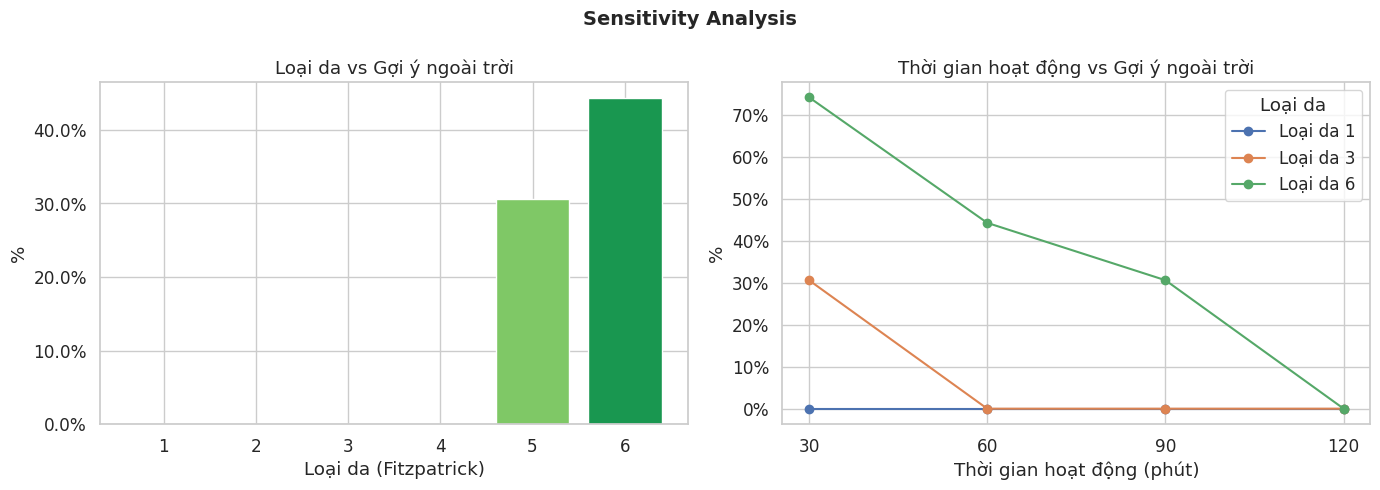

 Skin Type  Outdoor %
         1   0.000000
         2   0.000000
         3   0.000000
         4   0.000000
         5  30.641623
         6  44.324699


In [15]:
import matplotlib.pyplot as plt, matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sensitivity Analysis', fontsize=14, fontweight='bold')

# Skin type
skin_data = [(st, (safe_minutes(df_test_day['uv_predicted'].values, st) >= ACTIVITY_MIN).mean()*100)
             for st in range(1, 7)]
st_vals, st_pcts = zip(*skin_data)
axes[0].bar(st_vals, st_pcts, color=plt.cm.RdYlGn(np.linspace(0.2, 0.9, 6)))
axes[0].set_xlabel('Loại da (Fitzpatrick)'); axes[0].set_ylabel('%')
axes[0].set_title('Loại da vs Gợi ý ngoài trời')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter())

# Activity duration
for st in [1, 3, 6]:
    pcts = [(safe_minutes(df_test_day['uv_predicted'].values, st) >= dur).mean()*100
            for dur in [30, 60, 90, 120]]
    axes[1].plot([30,60,90,120], pcts, marker='o', label=f'Loại da {st}')
axes[1].set_xlabel('Thời gian hoạt động (phút)'); axes[1].set_ylabel('%')
axes[1].set_title('Thời gian hoạt động vs Gợi ý ngoài trời')
axes[1].legend(title='Loại da'); axes[1].set_xticks([30,60,90,120])
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout(); 
# plt.savefig('sensitivity.png', dpi=110, bbox_inches='tight'); 
plt.show()
print(pd.DataFrame(skin_data, columns=['Skin Type','Outdoor %']).to_string(index=False))

### 3f. Visualizations — Summary Dashboard

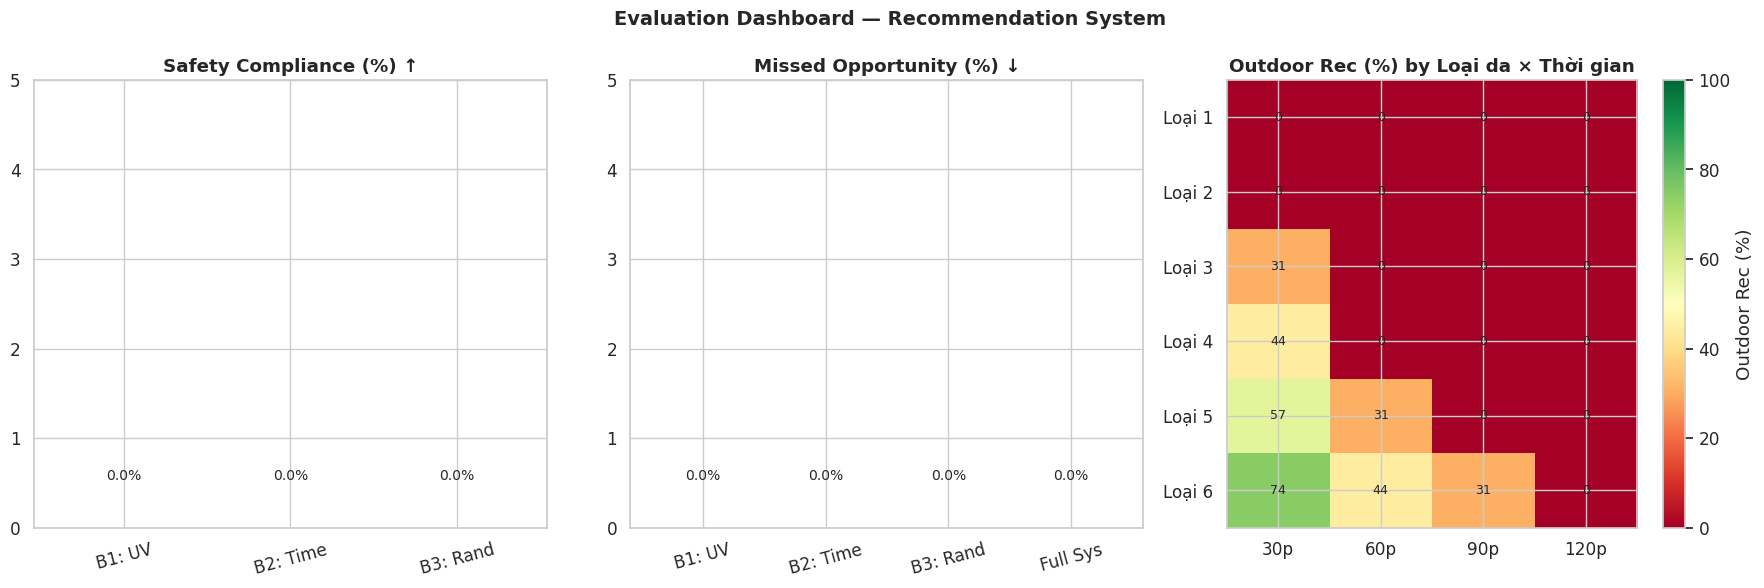


=== Full Evaluation Summary ===


,Safety Compliance (%),False Safety Rate (%),Missed Opportunity (%)
System,,,
Baseline 1: UV-Only (UV<3→outdoor),0.0,100.0,0.0
Baseline 2: Time-Only (6-9h & 16-18h),0.0,100.0,0.0
Baseline 3: Random (50/50),0.0,100.0,0.0
Full System (Regression WHO bins),NaN,NaN,0.0


In [16]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Evaluation Dashboard — Recommendation System', fontsize=14, fontweight='bold')

systems_short = ['B1: UV', 'B2: Time', 'B3: Rand', 'Full Sys']
sc_vals  = cmp_df['Safety Compliance (%)'].values
mo_vals  = cmp_df['Missed Opportunity (%)'].values
colors_g = ['#95a5a6','#7f8c8d','#bdc3c7','#27ae60']
colors_r = ['#e74c3c','#e67e22','#f39c12','#3498db']

for ax, vals, cols, title in [
    (axes[0], sc_vals,  colors_g, 'Safety Compliance (%) ↑'),
    (axes[1], mo_vals,  colors_r, 'Missed Opportunity (%) ↓'),
]:
    bars = ax.bar(systems_short, vals, color=cols, edgecolor='white')
    ax.set_title(title, fontweight='bold'); ax.set_ylim(0, max(vals)*1.25+5)
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
                f'{b.get_height():.1f}%', ha='center', va='bottom', fontsize=10)
    ax.tick_params(axis='x', labelrotation=15)

# Heatmap: skin type × duration
durations = [30, 60, 90, 120]
heat = np.array([
    [(safe_minutes(df_test_day['uv_predicted'].values, st) >= dur).mean()*100
     for dur in durations] for st in range(1, 7)
])
im = axes[2].imshow(heat, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100)
axes[2].set_xticks(range(4)); axes[2].set_xticklabels([f'{d}p' for d in durations])
axes[2].set_yticks(range(6)); axes[2].set_yticklabels([f'Loại {s}' for s in range(1,7)])
axes[2].set_title('Outdoor Rec (%) by Loại da × Thời gian', fontweight='bold')
plt.colorbar(im, ax=axes[2], label='Outdoor Rec (%)')
for si in range(6):
    for di in range(4):
        axes[2].text(di, si, f'{heat[si,di]:.0f}', ha='center', va='center', fontsize=9)

plt.tight_layout()
# plt.savefig('evaluation_dashboard.png', dpi=110, bbox_inches='tight')
plt.show()
print("\n=== Full Evaluation Summary ===")
display(cmp_df.set_index('System'))